In [276]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tools.eval_measures import rmse
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [2]:
pd.set_option('display.max_columns', None)

In [312]:
#df_socioecons = pd.read_csv('merged_data.csv') #WRONG DATA BECAUSE THERE ARE COUNTIES WITH SAME NAMES IN DIFFERENT STATES THAT ARE NOT INCLUDED IN THIS DATA
df_socioecons = pd.read_csv('training_data.csv')
df_socioecons.drop(columns = ['Unnamed: 0'], inplace = True)
df_socioecons.dropna(inplace = True)
df_socioecons.head(10)

,REP,DEM,Registerd,county_name,State,% age 25-34,% age 35-44,% age 45-54,% age 55-64,% age 65 or older,Median age,% Bachelor's,% HS diploma,% less than HS diploma,% post grad,% college,Average HH size,Median gross rent,Median value of an owner-occupied home,Median HH income,Median owner cost burden,Median renter cost burden,% Asian,% Black,% Hispanic,% White
0,0.646619,0.353381,14449,Abbeville,SC,10.288667,10.517500,11.790333,16.543667,24.078000,46.033333,12.328667,33.508333,21.140000,6.075833,27.879167,2.502167,728.833333,95739.999994,39557.233334,15.391667,33.148333,1.037333,9.143500,3.617500,86.376667
1,0.805878,0.194122,28039,Acadia,LA,14.357708,12.211417,12.420708,12.759250,13.154000,35.045833,10.851542,41.770625,21.567750,3.350500,23.449792,2.827750,667.325000,118608.333330,49745.220833,12.301250,26.236250,0.387383,17.377533,2.416433,79.292550
2,0.547582,0.452418,16750,Accomack,VA,11.056632,11.274000,13.029625,16.301854,21.739076,45.357639,11.415590,40.923028,19.439729,5.816313,21.203090,2.373333,797.656250,152720.486112,40916.204861,16.405556,28.705208,3.330545,32.345016,6.887462,58.932408
3,0.520220,0.479780,251238,Ada,ID,13.846994,13.671397,13.513508,12.722110,14.538925,38.651110,24.630828,22.703758,5.829241,13.087833,33.881058,2.534280,1041.757567,258447.737760,65698.628093,17.986236,27.683560,1.134933,0.454400,3.525526,93.455696
4,0.709042,0.290958,4114,Adair,IA,10.295694,10.963889,12.862500,16.609722,20.438611,45.236111,13.764306,41.704583,6.169028,4.004444,33.744444,2.269861,657.500000,114511.111117,57052.472222,15.975000,23.056944,1.824444,3.026111,9.036944,89.092500
5,0.839488,0.160512,8666,Adair,KY,10.607209,10.968155,15.884418,13.406773,19.528491,42.800000,7.791255,41.895900,22.564736,5.709409,22.236891,2.474182,576.675455,81733.000000,35316.107272,15.166182,28.397636,1.571681,1.078967,1.494652,95.143105
6,0.633023,0.366977,10096,Adair,MO,9.399429,9.396452,14.373690,11.326024,17.635905,40.100000,13.489976,36.726095,12.558429,10.720167,26.377310,2.302667,655.516667,114320.000000,47032.766668,15.045000,26.295000,0.104571,1.960000,2.180571,95.797071
7,0.800922,0.199078,6942,Adair,OK,10.771333,12.328833,12.890333,14.242000,17.051833,41.366667,11.055167,40.255167,18.193833,3.879500,25.541000,2.795167,628.800000,89841.666666,36973.133334,14.510000,24.590000,6.773730,6.370857,17.818111,77.615937
8,0.416434,0.583566,227825,Adams,CO,15.980062,14.239491,13.073364,11.541704,10.296979,35.091675,16.623436,27.803963,17.016538,8.010409,30.548922,2.908407,1381.200909,264961.809924,72048.249049,19.559799,31.704912,1.628713,4.502853,17.183609,87.270544
9,0.721435,0.278565,2118,Adams,IA,10.651875,9.781250,12.557375,17.010375,21.922625,47.000000,13.405125,39.685625,6.086375,3.675875,37.613875,2.191000,559.437500,94506.250000,51768.512500,15.020000,18.696250,2.998028,4.015542,16.979611,83.391000


In [313]:
df_socioecons[df_socioecons['Registerd'] == 0]

,REP,DEM,Registerd,county_name,State,% age 25-34,% age 35-44,% age 45-54,% age 55-64,% age 65 or older,Median age,% Bachelor's,% HS diploma,% less than HS diploma,% post grad,% college,Average HH size,Median gross rent,Median value of an owner-occupied home,Median HH income,Median owner cost burden,Median renter cost burden,% Asian,% Black,% Hispanic,% White


In [314]:
df_socioecons.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2886 entries, 0 to 2888
Data columns (total 26 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   REP                                     2886 non-null   float64
 1   DEM                                     2886 non-null   float64
 2   Registerd                               2886 non-null   int64  
 3   county_name                             2886 non-null   object 
 4   State                                   2886 non-null   object 
 5   % age 25-34                             2886 non-null   float64
 6   % age 35-44                             2886 non-null   float64
 7   % age 45-54                             2886 non-null   float64
 8   % age 55-64                             2886 non-null   float64
 9   % age 65 or older                       2886 non-null   float64
 10  Median age                              2886 non-null   floa

In [315]:
len(df_socioecons)

2886

In [316]:
df_socioecons

,REP,DEM,Registerd,county_name,State,% age 25-34,% age 35-44,% age 45-54,% age 55-64,% age 65 or older,Median age,% Bachelor's,% HS diploma,% less than HS diploma,% post grad,% college,Average HH size,Median gross rent,Median value of an owner-occupied home,Median HH income,Median owner cost burden,Median renter cost burden,% Asian,% Black,% Hispanic,% White
0,0.646619,0.353381,14449,Abbeville,SC,10.288667,10.517500,11.790333,16.543667,24.078000,46.033333,12.328667,33.508333,21.140000,6.075833,27.879167,2.502167,728.833333,95739.999994,39557.233334,15.391667,33.148333,1.037333,9.143500,3.617500,86.376667
1,0.805878,0.194122,28039,Acadia,LA,14.357708,12.211417,12.420708,12.759250,13.154000,35.045833,10.851542,41.770625,21.567750,3.350500,23.449792,2.827750,667.325000,118608.333330,49745.220833,12.301250,26.236250,0.387383,17.377533,2.416433,79.292550
2,0.547582,0.452418,16750,Accomack,VA,11.056632,11.274000,13.029625,16.301854,21.739076,45.357639,11.415590,40.923028,19.439729,5.816313,21.203090,2.373333,797.656250,152720.486112,40916.204861,16.405556,28.705208,3.330545,32.345016,6.887462,58.932408
3,0.520220,0.479780,251238,Ada,ID,13.846994,13.671397,13.513508,12.722110,14.538925,38.651110,24.630828,22.703758,5.829241,13.087833,33.881058,2.534280,1041.757567,258447.737760,65698.628093,17.986236,27.683560,1.134933,0.454400,3.525526,93.455696
4,0.709042,0.290958,4114,Adair,IA,10.295694,10.963889,12.862500,16.609722,20.438611,45.236111,13.764306,41.704583,6.169028,4.004444,33.744444,2.269861,657.500000,114511.111117,57052.472222,15.975000,23.056944,1.824444,3.026111,9.036944,89.092500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2884,0.532717,0.467283,65609,Yuma,AZ,11.690674,11.913663,10.508008,11.467101,17.912618,37.943389,8.152121,27.363950,30.450537,3.869423,29.750883,2.724683,744.475000,110821.416670,43137.655834,16.539417,29.529167,0.143000,1.653917,29.900750,90.843000
2885,0.841042,0.158958,4800,Yuma,CO,11.804048,10.887619,12.432619,12.498810,17.883333,37.714286,15.163333,31.323810,13.759286,6.408095,34.394048,3.126667,757.547619,171045.238100,49239.690476,14.752381,26.345238,2.726905,6.264708,18.185628,78.008528
2886,0.527518,0.472482,3852,Zapata,TX,11.562222,10.762222,10.167778,8.155556,12.602222,28.222222,5.988889,24.071111,45.856667,4.505556,18.286667,2.768889,494.777778,66300.000000,29566.888890,13.233333,32.866667,0.379653,1.075947,62.138507,87.103829
2887,0.342214,0.657786,4354,Zavala,TX,11.677222,12.371111,12.193889,10.218333,12.681667,30.777778,6.059444,26.883889,42.150000,2.228889,22.432222,3.380000,601.444444,49644.444443,25880.777777,13.372222,32.572222,0.068333,0.246667,40.903333,91.505000


In [317]:
df_socioecons.corr()

,REP,DEM,Registerd,% age 25-34,% age 35-44,% age 45-54,% age 55-64,% age 65 or older,Median age,% Bachelor's,% HS diploma,% less than HS diploma,% post grad,% college,Average HH size,Median gross rent,Median value of an owner-occupied home,Median HH income,Median owner cost burden,Median renter cost burden,% Asian,% Black,% Hispanic,% White
REP,1.000000,-1.000000,-0.375237,-0.300932,-0.138167,-0.048096,0.099197,0.212020,0.163804,-0.440203,0.479088,0.098553,-0.578505,0.107282,-0.125477,-0.543571,-0.510472,-0.313591,-0.576875,-0.366288,-0.260594,-0.148210,-0.025000,0.195184
DEM,-1.000000,1.000000,0.375237,0.300932,0.138167,0.048096,-0.099197,-0.212020,-0.163804,0.440203,-0.479088,-0.098553,0.578505,-0.107282,0.125477,0.543571,0.510472,0.313591,0.576875,0.366288,0.260594,0.148210,0.025000,-0.195184
Registerd,-0.375237,0.375237,1.000000,0.312284,0.211148,0.050119,-0.195715,-0.195236,-0.163931,0.346221,-0.339936,-0.073917,0.388113,-0.089325,0.177144,0.509957,0.403478,0.329961,0.357718,0.206238,0.257313,0.049127,0.126578,-0.126290
% age 25-34,-0.300932,0.300932,0.312284,1.000000,0.455610,-0.106185,-0.587921,-0.648884,-0.656360,0.107016,-0.259020,0.243862,0.189604,-0.195877,0.271673,0.299263,0.176712,0.136443,0.124702,0.143380,0.117419,0.176294,0.126122,-0.195065
% age 35-44,-0.138167,0.138167,0.211148,0.455610,1.000000,0.233991,-0.496238,-0.639130,-0.519656,0.057909,-0.082273,0.152536,0.116292,-0.216291,0.297468,0.289206,0.168705,0.251363,0.117404,0.107014,0.093572,0.169470,-0.004438,-0.132710
% age 45-54,-0.048096,0.048096,0.050119,-0.106185,0.233991,1.000000,0.098505,-0.129689,0.153408,-0.002718,0.196474,-0.067800,0.091026,-0.236833,-0.079140,0.191350,0.137622,0.256977,0.226880,0.089104,0.049370,0.098454,-0.248434,0.012174
% age 55-64,0.099197,-0.099197,-0.195715,-0.587921,-0.496238,0.098505,1.000000,0.669982,0.824309,0.042229,0.158626,-0.369994,-0.055490,0.236762,-0.459282,-0.155547,0.012808,-0.060048,0.032719,-0.081548,-0.039103,-0.171281,-0.180177,0.154379
% age 65 or older,0.212020,-0.212020,-0.195236,-0.648884,-0.639130,-0.129689,0.669982,1.000000,0.902418,-0.083701,0.159025,-0.169661,-0.109472,0.158946,-0.403649,-0.250511,-0.085587,-0.286277,-0.084073,-0.005628,-0.042135,-0.143353,-0.002977,0.110858
Median age,0.163804,-0.163804,-0.163931,-0.656360,-0.519656,0.153408,0.824309,0.902418,1.000000,-0.000930,0.183842,-0.304629,-0.034215,0.154729,-0.471407,-0.149960,0.007309,-0.126201,0.025182,-0.009326,-0.016018,-0.141110,-0.132174,0.130065
% Bachelor's,-0.440203,0.440203,0.346221,0.107016,0.057909,-0.002718,0.042229,-0.083701,-0.000930,1.000000,-0.712202,-0.623175,0.755615,0.160353,0.014681,0.647552,0.679304,0.734040,0.398472,-0.059316,0.230253,-0.121984,0.061379,-0.009090


C:\Users\jorda\anaconda3\lib\site-packages\ipykernel_launcher.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  # Remove the CWD from sys.path while we load stuff.


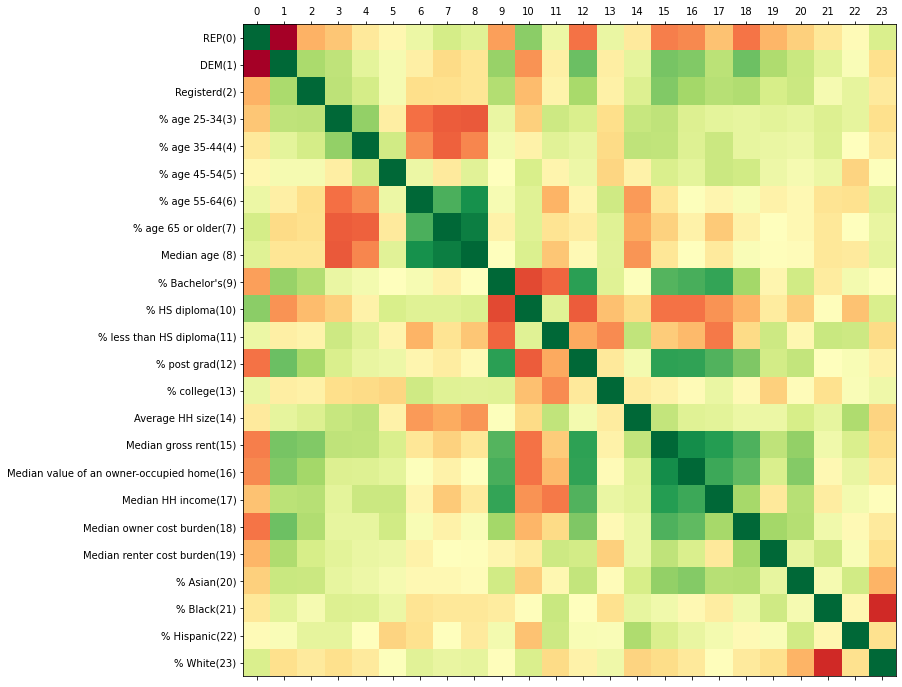

In [318]:
# Heatmap of correlation matrix
labels = [c for c in df_socioecons.corr().columns]

for index, value in enumerate(labels):
    labels[index] = value + f"({index})"

fig1, ax_corr = plt.subplots(figsize = (12, 12))

#ax_corr.set_xticklabels(labels)
ax_corr.set_yticklabels(labels)

ax_corr.matshow(df_socioecons.corr(), cmap = plt.cm.RdYlGn)
ax_corr.set_xticks(np.arange(len(labels)))
ax_corr.set_yticks(np.arange(len(labels)))
plt.show()

In [319]:
w, v = np.linalg.eig(df_socioecons.corr())

In [320]:
w

array([ 6.89527055e+00,  4.14447551e+00,  2.29076397e+00,  1.83449144e+00,
        1.44775087e+00,  1.29656420e+00,  8.28314974e-01,  7.48422226e-01,
        7.24476421e-01,  6.37034713e-01,  5.77919330e-01,  4.45052217e-01,
        4.12450981e-01,  3.81250065e-01,  3.44207862e-01,  2.54040388e-01,
        2.39844099e-01, -5.14710716e-16,  4.78812243e-03,  2.58929591e-02,
        1.60605765e-01,  1.44244357e-01,  7.06759983e-02,  9.14629855e-02])

In [321]:
df_cleaned = df_socioecons.drop(columns = ['REP',
                                           'county_name', 
                                           'State'])

df_county_state = df_socioecons[['county_name', 'State']]

y = df_cleaned['DEM'] 
X = df_cleaned.drop(columns = ['DEM'])
#X = sm.add_constant(X)

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.10)

<h1>Normal Linear Regression</h1>

In [300]:
# 10-fold Cross Validation 
cross_val_score(LinearRegression(), X, y, cv = 10) #R^2 value

array([0.52544652, 0.50077231, 0.5782975 , 0.52021034, 0.48120302,
       0.44931668, 0.55463959, 0.52265262, 0.50483283, 0.51976971])

In [301]:
help(LinearRegression.score)

Help on function score in module sklearn.base:

score(self, X, y, sample_weight=None)
    Return the coefficient of determination R^2 of the prediction.
    
    The coefficient R^2 is defined as (1 - u/v), where u is the residual
    sum of squares ((y_true - y_pred) ** 2).sum() and v is the total
    sum of squares ((y_true - y_true.mean()) ** 2).sum().
    The best possible score is 1.0 and it can be negative (because the
    model can be arbitrarily worse). A constant model that always
    predicts the expected value of y, disregarding the input features,
    would get a R^2 score of 0.0.
    
    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Test samples. For some estimators this may be a
        precomputed kernel matrix or a list of generic objects instead,
        shape = (n_samples, n_samples_fitted),
        where n_samples_fitted is the number of
        samples used in the fitting for the estimator.
    
    y : array-like of shape (n

In [302]:
y2 = df_cleaned['DEM'] # Expressed in terms of the actual ratio
X2 = df_cleaned.drop(columns = ['DEM'])

scaler = StandardScaler()
X2 = scaler.fit_transform(X2)

In [303]:
X2

array([[-0.23456062, -0.36196025, -0.56444488, ...,  0.05276503,
        -0.42284274,  0.20431043],
       [-0.13164624,  1.5950124 ,  0.59163096, ...,  0.74132249,
        -0.51739198, -0.31134015],
       [-0.2171356 ,  0.00738643, -0.04814358, ...,  1.99295352,
        -0.16542785, -1.79334834],
       ...,
       [-0.3148096 ,  0.25054598, -0.39742518, ..., -0.62187081,
         4.18399306,  0.25724035],
       [-0.31100805,  0.3058543 ,  0.70062032, ..., -0.691218  ,
         2.51233765,  0.57760016],
       [-0.3372781 ,  0.46429794,  1.9761124 , ..., -0.68843055,
        -0.61096421,  0.75468128]])

In [323]:
cross_val_score(LinearRegression(), X2, y2, scoring = 'neg_mean_squared_error', cv = 10)

array([-0.01235123, -0.01058726, -0.01153853, -0.01100867, -0.01368648,
       -0.01174997, -0.01305828, -0.01313058, -0.01472325, -0.01102691])

In [325]:
np.mean(cross_val_score(LinearRegression(), X2, y2, scoring = 'neg_mean_squared_error', cv = 10))

-0.01228611759262643

In [336]:
cross_val_score(LinearRegression(), X2, y2, cv = 10)

array([0.52544652, 0.50077231, 0.5782975 , 0.52021034, 0.48120302,
       0.44931668, 0.55463959, 0.52265262, 0.50483283, 0.51976971])

In [337]:
np.mean(cross_val_score(LinearRegression(), X2, y2, cv = 10))

0.5157141102699858

<h2>Ridge Regression</h2>

In [326]:
# Ridge
ridge = Ridge()
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 30, 35, 40, 45, 50, 55, 100]}
ridge_regressor = GridSearchCV(ridge, parameters, scoring = 'neg_mean_squared_error', cv = 10)
ridge_regressor.fit(X2, y2)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')

In [327]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 10}
-0.012281101460315335


In [338]:
ridge_regressor = GridSearchCV(ridge, parameters, scoring = 'r2', cv = 10)
ridge_regressor.fit(X2, y2)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   30, 35, 40, 45, 50, 55, 100]},
             scoring='r2')

In [339]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 10}
0.5159195427919021


<h2>LASSO Regression</h2>

In [328]:
# LASSO 
lasso = Lasso()
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 30, 35, 40, 45, 50, 55, 100]}
lasso_regressor = GridSearchCV(lasso, parameters, scoring = 'neg_mean_squared_error', cv = 10)
lasso_regressor.fit(X2, y2)

C:\Users\jorda\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 15.457899688430652, tolerance: 0.006647324603040892
  positive)
C:\Users\jorda\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 15.709403909487627, tolerance: 0.00678421223831177
  positive)
C:\Users\jorda\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 15.577745331648478, tolerance: 0.006608892766299255
  positive)
C:\Users\jorda\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')

In [329]:
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

{'alpha': 0.001}
-0.012279046913914259


In [340]:
lasso_regressor = GridSearchCV(lasso, parameters, scoring = 'r2', cv = 10)
lasso_regressor.fit(X2, y2)

C:\Users\jorda\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 15.457899688430652, tolerance: 0.006647324603040892
  positive)
C:\Users\jorda\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 15.709403909487627, tolerance: 0.00678421223831177
  positive)
C:\Users\jorda\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 15.577745331648478, tolerance: 0.006608892766299255
  positive)
C:\Users\jorda\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   30, 35, 40, 45, 50, 55, 100]},
             scoring='r2')

In [341]:
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

{'alpha': 0.001}
0.5161093366371792


<h1>PCR</h1>

In [356]:
y3 = df_cleaned['DEM'] # Expressed in terms of the actual ratio
X3 = df_cleaned.drop(columns = ['DEM'])

scaler = StandardScaler()
X3 = scaler.fit_transform(X3)

pca = PCA(n_components = 20)
X3_reduced = pca.fit_transform(X3)

In [357]:
X3_reduced

array([[-1.53877866,  0.10786321,  1.39836186, ..., -0.62693136,
        -0.05247495, -0.18343581],
       [-0.49626565, -4.0390667 , -0.62009267, ...,  0.0380934 ,
        -0.18789231,  0.0615577 ],
       [-0.73638863, -0.93245528,  3.23913299, ..., -0.06323332,
        -0.12956151, -0.33235878],
       ...,
       [-0.74253571, -6.82511428, -0.36472244, ...,  0.1754122 ,
         0.09713325,  0.49480443],
       [-0.71517651, -6.70127849, -0.41935771, ...,  0.06307453,
        -0.1338941 , -0.13241344],
       [ 0.27228724, -3.58304919, -3.24694663, ...,  0.37912045,
        -0.12150406, -0.5336817 ]])

In [358]:
pca.explained_variance_ratio_

array([0.27220639, 0.18819422, 0.09864848, 0.08328613, 0.06081657,
       0.04984528, 0.03728618, 0.03357539, 0.03060285, 0.02635577,
       0.02100401, 0.01875573, 0.01771404, 0.01566474, 0.01201714,
       0.01132087, 0.00732794, 0.00660388, 0.00416308, 0.00321335])

In [359]:
pca.explained_variance_ratio_.cumsum() # Want to obtain at least 0.95 explained variance, so number of components = 14

array([0.27220639, 0.46040061, 0.55904909, 0.64233522, 0.70315179,
       0.75299707, 0.79028325, 0.82385864, 0.85446149, 0.88081725,
       0.90182127, 0.920577  , 0.93829103, 0.95395577, 0.96597291,
       0.97729378, 0.98462172, 0.9912256 , 0.99538868, 0.99860203])

Text(0, 0.5, 'Explained Variance')

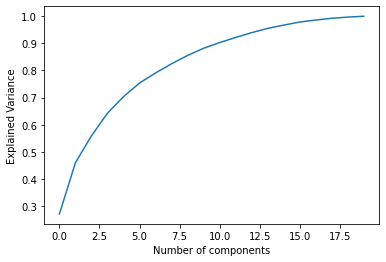

In [362]:
plt.plot(range(0,20), pca.explained_variance_ratio_.cumsum())
plt.xlabel('Number of components')
plt.ylabel('Explained Variance')

In [271]:
pca = PCA(n_components = 14)
X3_reduced = pca.fit_transform(X3)

In [330]:
cross_val_score(LinearRegression(), X3_reduced, y3, scoring = 'neg_mean_squared_error', cv = 10)

array([-0.01329813, -0.01164736, -0.01190451, -0.01244955, -0.01341613,
       -0.01174921, -0.01366856, -0.01331238, -0.01574477, -0.01212643])

In [331]:
np.mean(cross_val_score(LinearRegression(), X3_reduced, y3, scoring = 'neg_mean_squared_error', cv = 10))

-0.012931705020875022

In [342]:
cross_val_score(LinearRegression(), X3_reduced, y3, cv = 10)

array([0.48906528, 0.45078452, 0.5649217 , 0.45741252, 0.49145106,
       0.44935245, 0.53382559, 0.51604345, 0.47047744, 0.47188471])

In [343]:
np.mean(cross_val_score(LinearRegression(), X3_reduced, y3, cv = 10))

0.48952187202512515

<h1>PCR Ridge</h1>

In [332]:
# Ridge
ridge = Ridge()
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 30, 35, 40, 45, 50, 55, 100]}
ridge_regressor = GridSearchCV(ridge, parameters, scoring = 'neg_mean_squared_error', cv = 10)
ridge_regressor.fit(X3_reduced, y3)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')

In [333]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 100}
-0.01292442597319203


In [344]:
ridge_regressor = GridSearchCV(ridge, parameters, scoring = 'r2', cv = 10)
ridge_regressor.fit(X3_reduced, y3)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   30, 35, 40, 45, 50, 55, 100]},
             scoring='r2')

In [345]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 100}
0.4898273194199817


<h2>PCR LASSO</h2>

In [350]:
# LASSO 
lasso = Lasso()
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 30, 35, 40, 45, 50, 55, 100]}
lasso_regressor = GridSearchCV(lasso, parameters, scoring = 'neg_mean_squared_error', cv = 10)
lasso_regressor.fit(X3_reduced, y3)

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')

In [351]:
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

{'alpha': 1e-15}
-0.012931705020875022


In [352]:
lasso_regressor = GridSearchCV(lasso, parameters, scoring = 'r2', cv = 10)
lasso_regressor.fit(X3_reduced, y3)

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   30, 35, 40, 45, 50, 55, 100]},
             scoring='r2')

In [353]:
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

{'alpha': 1e-15}
0.48952187202512504
